In [61]:
import matplotlib.pyplot as plt
%matplotlib widget

In [67]:
from abc import ABC

class Module(ABC):
    def coordinate_transform(self, coordinates):
        raise NotImplementedError()
        
    def image_transform(self, image):
        raise NotImplementedError()
        
    def metadata_transform(self, metadata):
        raise NotImplementedError()
        
    def get_cache(self):
        raise NotImplementedError()

In [68]:
import numpy as np

class SegmentModule(Module):
    def __init__(self, padding_size):
        self.padding_size = padding_size
        
    def coordinate_transform(self, coordinates):
        return coordinates[0] - self.padding_size, coordinates[1] + self.padding_size
    
    def image_transform(self, image):
        return (image > 128)[self.padding_size:-self.padding_size, self.padding_size:-self.padding_size]
    
    def metadata_transform(self, metadata):
        metadata["type"] = "segmentation"
        return metadata
    
    def get_cache(self):
        return f"{type(self)}-{self.padding_size}"

In [69]:
class GrayscaleModule(Module):
    def coordinate_transform(self, coordinates):
        return coordinates
    
    def metadata_transform(self, metadata):
        return metadata
    
    def image_transform(self, image):
        return image[..., 0]

In [96]:
from imageio import imread

class ImageModule(object):
    def get_crop(self, fname, coordinates):
        xy_from, xy_to = coordinates
        image = imread(fname)
        return image[xy_from[1]:xy_to[1], xy_from[0]:xy_to[0]]
    
    def get_metadata(self, fname):
        return {
            "fname": fname,
            "type": "image",
            # read this from the image
            # "size": (42, 42), 
        }

In [97]:
class PNGEncoder(object):
    def encode_image(self, image):
        # no idea how to do that
        return str(image)

In [92]:
def get_image_module(fname):
    if "jpeg" in fname:
        return ImageModule
    raise RuntimeError()

In [77]:
io_module = ImageModule()
res = io_module.get_crop("/home/cschiffer/Bilder/Koala.jpeg", [[0, 0], [100, 100]])

/tmp/ipykernel_3933809/1625977396.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imread(fname)


In [86]:
modules = [
    # SegmentModule(40),
    # GrayscaleModule(),
]

In [100]:
# client
fname = "/home/cschiffer/Bilder/Koala.jpeg"
coords = np.array([[200, 200], [400, 400]])
# forward
for module in modules:
    coords = module.coordinate_transform(coords)
# reading image
image_module = get_image_module(fname)()
img = image_module.get_crop(fname, coords)
# backward
for module in modules[::-1]:
    img = module.image_transform(img)
# output module
output_module = PNGEncoder()
result = output_module.encode_image(img)
print(result)

[[[179 202 158]
  [180 201 162]
  [180 200 165]
  ...
  [150 128 114]
  [129 107  93]
  [133 117  94]]

 [[184 208 160]
  [182 205 163]
  [182 203 164]
  ...
  [143 120 106]
  [115  96  81]
  [147 130 110]]

 [[186 210 162]
  [185 207 161]
  [183 204 163]
  ...
  [125 103  89]
  [120  98  84]
  [139 122 102]]

 ...

 [[160 143 127]
  [162 145 129]
  [167 150 134]
  ...
  [108  47  16]
  [122  61  30]
  [126  65  36]]

 [[164 147 131]
  [163 146 130]
  [183 164 149]
  ...
  [111  50  19]
  [124  63  32]
  [123  62  33]]

 [[172 156 141]
  [175 159 144]
  [193 175 161]
  ...
  [113  50  19]
  [120  61  27]
  [117  63  27]]]


/tmp/ipykernel_3933809/1625977396.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imread(fname)


In [95]:
# client
fname = "/home/cschiffer/Bilder/Koala.jpeg"
# image
image_module = get_image_module(fname)()
img = image_module.get_crop(fname, coords)
metadata = image_module.get_metadata(fname)
for module in modules[::-1]:
    metadata = module.metadata_transform(metadata)
metadata

/tmp/ipykernel_3933809/1625977396.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imread(fname)


{'fname': '/home/cschiffer/Bilder/Koala.jpeg', 'type': 'image'}

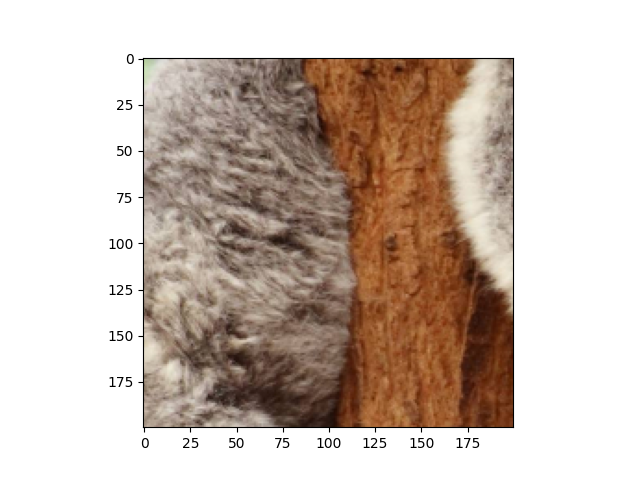

In [89]:
fig, ax = plt.subplots(1, 1)
ax.imshow(img)

In [41]:
img.dtype

dtype('bool')